## Customer Segmentation & Revenue Leakage Analysis Using RFM and K-Means

## 1️⃣ 🎯 Business Understanding

The company aims to understand customer behavior in order to:
- Identify high-value customers
- Reduce revenue leakage caused by product returns
- Improve customer retention and marketing strategies

Approaches used:
- Return Analysis
- Purchase Analysis
- RFM Segmentation
- Clustering (K-Means)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Data/OnlineRetail.csv', encoding='latin1')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


##  2️⃣Data Cleaning

In [6]:
# Missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
# Remove Missing CustomerID column
df = df.dropna(subset='CustomerID')

In [8]:
# Convert the column InvoiceDate type to Datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
# Convert the column CustomerID type to integer
df['CustomerID'] = df['CustomerID'].astype(int)

In [10]:
# Remove negative/zero column Quantity
df_clean = df[df['Quantity'] > 0].copy()

In [11]:
# Remove negative/zero column UnitPrice
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [12]:
# Create column TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

## 💡 Insight

The dataset has been cleaned from missing values, invalid transactions, and anomalies, making it ready for further analysis.

## 3️⃣ Return Analysis

In [13]:
df_return = df[df['Quantity'] < 0]

In [14]:
df_return.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


In [15]:
# Create column TotalPrice df_return
df_return['TotalPrice'] = df_return['Quantity'] * df_return['UnitPrice']

In [16]:
# Calculate return rate per customers
return_summary = df_return.groupby('CustomerID')[['Quantity', 'TotalPrice']].sum().abs().reset_index()
return_summary.columns = ['CustomerID','TotalReturnQty','TotalReturnPrice']

In [17]:
return_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,1589.0,15183.020768,1723.587032,12346.00,13709.00,15135.0,16660.0,18282.0
TotalReturnQty,1589.0,172.943990,2789.793293,1.00,3.00,8.0,26.0,80995.0
TotalReturnPrice,1589.0,384.733851,4888.766776,0.42,13.35,31.6,84.1,168469.6


In [18]:
# Top 10 return summary (total return quantities)

top10_returnqty = return_summary.sort_values('TotalReturnQty', ascending=False).head(10)

print("Top 10 Total Return Quantities per customer")
print('='*45)
print(top10_returnqty[['CustomerID','TotalReturnQty']].to_string(index=False))

Top 10 Total Return Quantities per customer
 CustomerID  TotalReturnQty
      16446           80995
      12346           74215
      15838            9361
      15749            9014
      16029            8060
      12931            4627
      14607            3768
      14911            3335
      17949            2975
      12901            2160


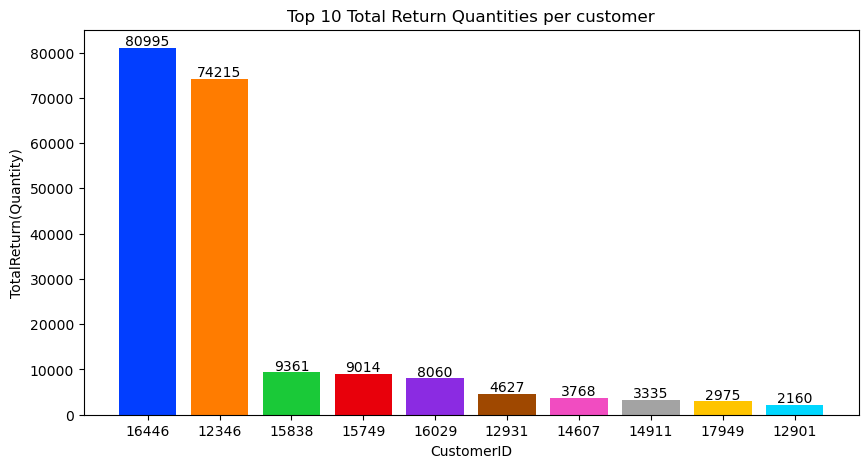

Summary Total Return Quantites 

Total Customer: 1589
Mean Total Return Quantities: 172.94
Median Total Return Quantities: 8.0
Max Total Return Quantities: 80995


In [19]:
plt.figure(figsize=(10,5), dpi=100)

ax = plt.bar(range(len(top10_returnqty)), top10_returnqty['TotalReturnQty'].values, color=sns.color_palette('bright'))

for p in ax.patches:
    height = p.get_height()
    plt.text(x = p.get_x() + p.get_width()/2, 
            y = height + 500, 
            s = '{:.0f}'.format(height), 
            ha = 'center'
           )
plt.title('Top 10 Total Return Quantities per customer')
plt.xlabel('CustomerID')
plt.ylabel('TotalReturn(Quantity)')
plt.xticks(range(len(top10_returnqty)), top10_returnqty['CustomerID'].values)
plt.show()

# summary
print('Summary Total Return Quantites \n')
print(f'Total Customer: {len(return_summary)}')
print(f"Mean Total Return Quantities: {return_summary['TotalReturnQty'].mean():.2f}")
print(f"Median Total Return Quantities: {return_summary['TotalReturnQty'].median()}")
print(f"Max Total Return Quantities: {return_summary['TotalReturnQty'].max()}")

## 💡 Insight

The plot shows that a small number of customers have significantly higher return quantities compared to the majority. This indicates an extreme imbalance in return behavior, which may be caused by product quality issues, operational errors, or misuse of return policies.

Therefore, the company should monitor and investigate customers with high return activity to reduce negative impacts on operational costs and efficiency.

------
-----

In [20]:
# Top 10 return summary (total return price)

top10_returnprice = return_summary.sort_values('TotalReturnPrice', ascending=False).head(10)

print("Top 10 Total Return Price per Customer")
print("="*45)
print(top10_returnprice[['CustomerID','TotalReturnPrice']].to_string(index=False))

Top 10 Total Return Price per Customer
 CustomerID  TotalReturnPrice
      16446         168469.60
      12346          77183.60
      15098          39267.00
      16029          30032.23
      15749          22998.40
      12744          12158.90
      14911          11252.44
      12931           8593.15
      12536           8495.01
      14096           8043.88


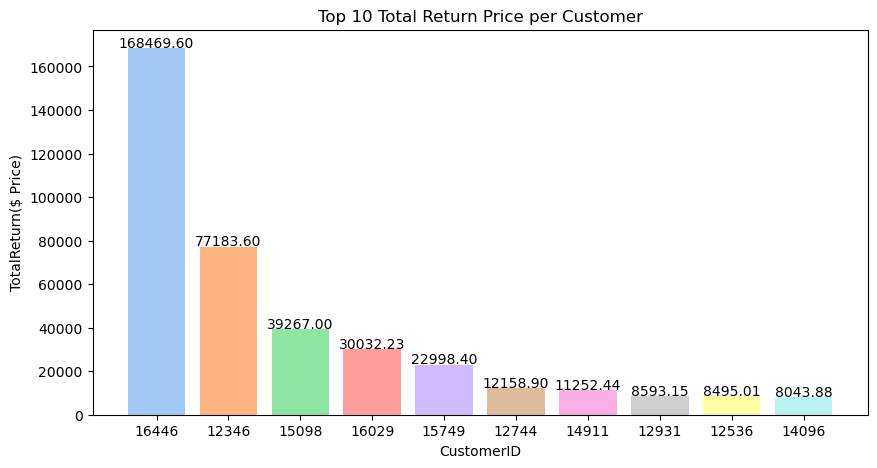

Summary Total Return Price 

Total customer : 1589
Mean Total Return Price  : $ 384.73
Median Total Return Price  : $ 31.60
Max Total Return Price  : $ 168469.6


In [21]:
plt.figure(figsize=(10,5), dpi=100)

ax = plt.bar(range(len(top10_returnprice)), top10_returnprice['TotalReturnPrice'].values, color=sns.color_palette('pastel'))

for p in ax.patches:
    height = p.get_height()
    plt.text(x = p.get_x() + p.get_width()/2, 
             y = height + 500, 
             s = '{:.2f}'.format(height), 
             ha = 'center'
            )
plt.title('Top 10 Total Return Price per Customer')
plt.xlabel('CustomerID')
plt.ylabel('TotalReturn($ Price)')
plt.xticks(range(len(top10_returnprice)), top10_returnprice['CustomerID'])
plt.show()

# summary
print("Summary Total Return Price \n")
print(f"Total customer : {len(return_summary)}")
print(f"Mean Total Return Price  : $ {return_summary['TotalReturnPrice'].mean():.2f}")
print(f"Median Total Return Price  : $ {return_summary['TotalReturnPrice'].median():.2f}")
print(f"Max Total Return Price  : $ {return_summary['TotalReturnPrice'].max()}")

## 💡 Insight

The plot indicates that a small number of customers contribute disproportionately to the total return value, with one customer having significantly higher returns than others. This imbalance suggests potential revenue leakage.

The company should closely monitor and evaluate high-return customers to minimize financial losses.

## 4️⃣ Purchase Analysis

In [22]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [23]:
purchase_summary = df_clean.groupby("CustomerID")[['Quantity','TotalPrice']].sum().reset_index()
purchase_summary.columns = ['CustomerID','TotalPurchaseQty','TotalPurchasePrice']

In [24]:
purchase_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4338.0,15300.408022,1721.808492,12346.00,13813.250,15299.500,16778.75,18287.00
TotalPurchaseQty,4338.0,1191.289073,5046.081546,1.00,160.000,379.000,992.75,196915.00
TotalPurchasePrice,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


In [25]:
# Top 10 purchase summary (Total purchase qty)
top10_purchaseqty = purchase_summary.sort_values('TotalPurchaseQty', ascending=False).head(10)

print('Top 10 Total Purchase quantities per Customer')
print('='*45)
print(top10_purchaseqty[['CustomerID','TotalPurchaseQty']].to_string(index=False))

Top 10 Total Purchase quantities per Customer
 CustomerID  TotalPurchaseQty
      14646            196915
      16446             80997
      14911             80265
      12415             77374
      12346             74215
      17450             69993
      17511             64549
      18102             64124
      13694             63312
      14298             58343


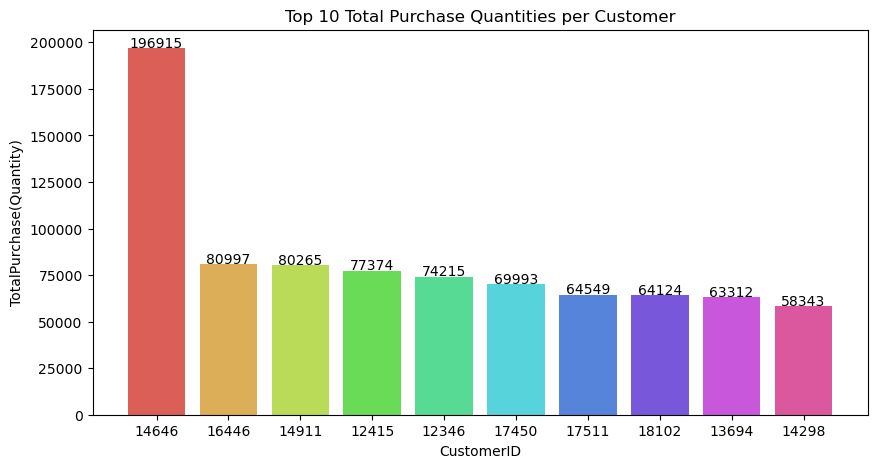

Summary Total Purchase Qty 

Total Customer: 4338
Mean Total Purchase qty: 1191.29
Median Total Purchase qty: 379.0
Max Total Purchase qty: 196915


In [26]:
plt.figure(figsize=(10,5), dpi=100)

ax = plt.bar(range(len(top10_purchaseqty)), top10_purchaseqty['TotalPurchaseQty'].values, color=sns.color_palette('hls', 10))

for p in ax.patches:
    height = p.get_height()
    plt.text(x = p.get_x() + p.get_width()/2, 
             y = height + 500, 
             s = '{:.0f}'.format(height), 
             ha = 'center'
            )
plt.title('Top 10 Total Purchase Quantities per Customer')
plt.xlabel('CustomerID')
plt.ylabel('TotalPurchase(Quantity)')
plt.xticks(range(len(top10_purchaseqty)), top10_purchaseqty['CustomerID'])
plt.show()

# summary
print("Summary Total Purchase Qty \n")
print(f"Total Customer: {len(purchase_summary)}")
print(f"Mean Total Purchase qty: {purchase_summary['TotalPurchaseQty'].mean():.2f}")
print(f"Median Total Purchase qty: {purchase_summary['TotalPurchaseQty'].median()}")
print(f"Max Total Purchase qty: {purchase_summary['TotalPurchaseQty'].max()}")

## 💡 Insight

The plot shows that one customer has a significantly higher purchase quantity compared to others, indicating a strong dependency on a specific customer segment. This creates a business risk if that customer stops purchasing.

Therefore, the company should retain high-value customers while also increasing the contribution from other customers to ensure business stability.

------
-----

In [27]:
top10_purchaseprice = purchase_summary.sort_values('TotalPurchasePrice', ascending=False).head(10)

print('Top 10 Total Purchase Price per Customer')
print('='*45)
print(top10_purchaseprice[['CustomerID','TotalPurchasePrice']].to_string(index=False))

Top 10 Total Purchase Price per Customer
 CustomerID  TotalPurchasePrice
      14646           280206.02
      18102           259657.30
      17450           194550.79
      16446           168472.50
      14911           143825.06
      12415           124914.53
      14156           117379.63
      17511            91062.38
      16029            81024.84
      12346            77183.60


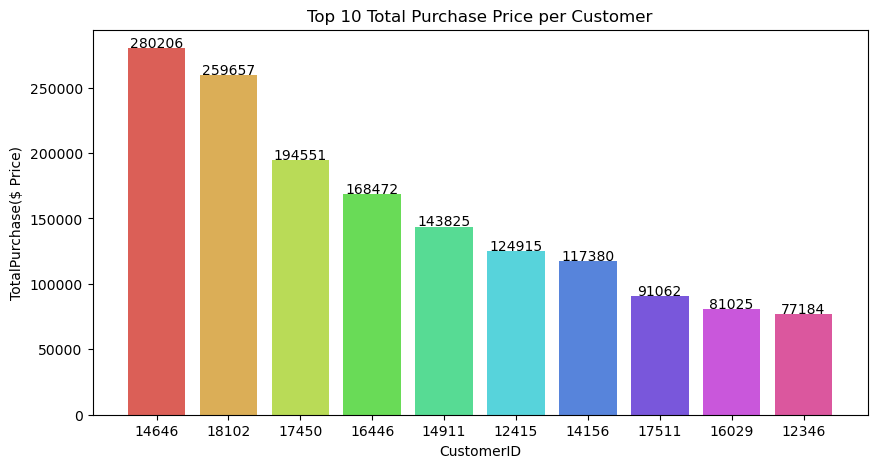

Summary Total Purchase Price 

Total Customer: 4338
Mean Total Purchase price: $ 2054.27
Median Total Purchase price: $ 674.485
Max Total Purchase price: $ 280206.02


In [28]:
plt.figure(figsize=(10,5), dpi=100)

ax = plt.bar(range(len(top10_purchaseprice)), top10_purchaseprice['TotalPurchasePrice'].values, color=sns.color_palette('hls', 10))

for p in ax.patches:
    height = p.get_height()
    plt.text(x = p.get_x() + p.get_width()/2, 
             y = height + 500, 
             s = '{:.0f}'.format(height), 
             ha = 'center'
            )
plt.title('Top 10 Total Purchase Price per Customer')
plt.xlabel('CustomerID')
plt.ylabel('TotalPurchase($ Price)')
plt.xticks(range(len(top10_purchaseprice)), top10_purchaseprice['CustomerID'])
plt.show()

# summary
print("Summary Total Purchase Price \n")
print(f"Total Customer: {len(purchase_summary)}")
print(f"Mean Total Purchase price: $ {purchase_summary['TotalPurchasePrice'].mean():.2f}")
print(f"Median Total Purchase price: $ {purchase_summary['TotalPurchasePrice'].median()}")
print(f"Max Total Purchase price: $ {purchase_summary['TotalPurchasePrice'].max()}")

## 💡 Insight

The plot shows that several customers contribute significantly to the company’s total revenue, with relatively high transaction values distributed across multiple customers. This indicates the presence of high-value customer segments.

The company should focus on retaining these customers while also increasing the value of other customers through targeted strategies.

##  5️⃣ Revenue Leakage

In [29]:
# Merge
customer_summary = pd.merge(purchase_summary, return_summary, on='CustomerID', how='left')

In [30]:
# Fill missing value 0
customer_summary[['TotalReturnQty','TotalReturnPrice']] = customer_summary[['TotalReturnQty','TotalReturnPrice']].fillna(0)

In [31]:
# Create column NetRevenue
customer_summary['NetRevenue'] = customer_summary['TotalPurchasePrice'] - customer_summary['TotalReturnPrice']

In [32]:
# Create column return rate %
customer_summary['ReturnRate_%'] = (customer_summary['TotalReturnPrice'] / customer_summary['TotalPurchasePrice'])*100

In [33]:
customer_summary.head()

,CustomerID,TotalPurchaseQty,TotalPurchasePrice,TotalReturnQty,TotalReturnPrice,NetRevenue,ReturnRate_%
0,12346,74215,77183.60,74215.0,77183.6,0.00,100.0
1,12347,2458,4310.00,0.0,0.0,4310.00,0.0
2,12348,2341,1797.24,0.0,0.0,1797.24,0.0
3,12349,631,1757.55,0.0,0.0,1757.55,0.0
4,12350,197,334.40,0.0,0.0,334.40,0.0


In [34]:
# Revenue Leakage

gross_revenue = customer_summary['TotalPurchasePrice'].sum()
total_return_value = customer_summary['TotalReturnPrice'].sum()
net_revenue = customer_summary['NetRevenue'].sum()
revenue_lakekage_percentage = (total_return_value / gross_revenue)*100

print(f"Gross Revenue : {gross_revenue}")
print(f"Total Return Value : {total_return_value}")
print(f"Revenue Lakelage:  {(revenue_lakekage_percentage):.2f}% ")

Gross Revenue : 8911407.904
Total Return Value : 600930.8500000001
Revenue Lakelage:  6.74% 


## 💡 Insight

The analysis shows that approximately 6.74% of total revenue is lost due to returns, indicating significant revenue leakage. Although the percentage may seem small, the actual impact on profit can be substantial due to additional operational costs such as logistics and handling.

Therefore, the company should identify the root causes of returns and improve policies and operational processes to reduce potential losses.

## 6️⃣ RFM Analysis

RFM is used to understand customer behavior based on:
- **Recency** (how recently a customer made a purchase)
- **Frequency** (how often a customer makes purchases)
- **Monetary** (how much a customer spends)

This approach helps identify high-value customers and customers at risk of churn.

In [35]:
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [36]:
today_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days= 1)

In [37]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x: (today_date - x.max()).days, 
    'InvoiceNo' : 'nunique', 
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

In [38]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


##  7️⃣ RFM Scoring

In [39]:
rfm['R_Score'] = pd.qcut(rfm['Recency'],5, labels = [5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],5, labels = [1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str) 

In [40]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112
5,12352,36,8,2506.04,3,5,5,355
6,12353,204,1,89.00,1,1,1,111
7,12354,232,1,1079.40,1,1,4,114
8,12355,214,1,459.40,1,1,2,112
9,12356,23,3,2811.43,4,3,5,435


## 8️⃣ RFM Segmentation

In [41]:
def segment_customer(row):
    r,f,m = row['R_Score'], row['F_Score'], row['M_Score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r >= 4 and f == 1:
        return 'New Customer'
    elif m >= 4 and f <= 2:
        return 'Big Spenders'
    else:
        return "Regular"
    
rfm['Segment_RFM'] = rfm.apply(segment_customer, axis= 1)

In [42]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment_RFM
0,12346,326,1,77183.60,1,1,5,115,Big Spenders
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,New Customer
4,12350,310,1,334.40,1,1,2,112,Regular


In [43]:
rfm['Segment_RFM'].value_counts()

Regular         2816
Champions        962
At Risk          275
Big Spenders     144
New Customer     141
Name: Segment_RFM, dtype: int64

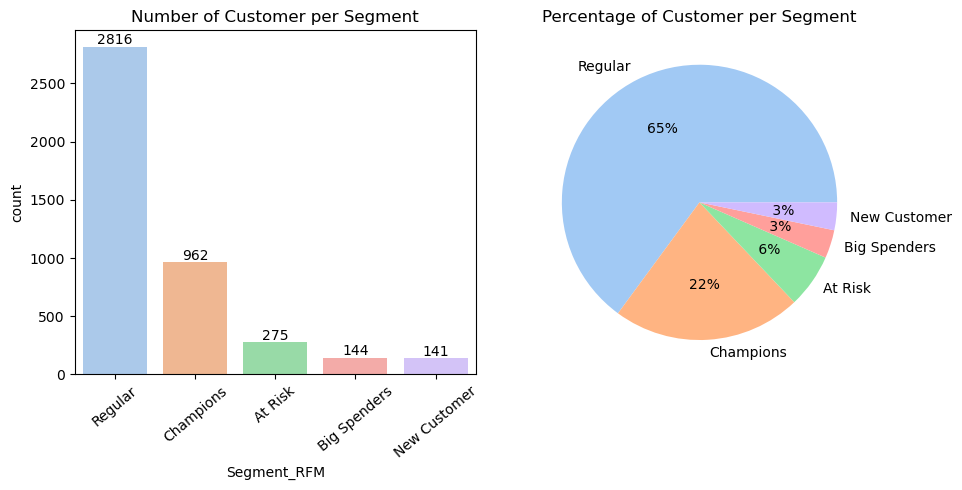

In [44]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)

ax = sns.countplot(x='Segment_RFM', data= rfm, order = rfm['Segment_RFM'].value_counts().index, palette='pastel')
for p in ax.patches:
    height = p.get_height()
    ax.text(x = p.get_x() + p.get_width()/2, 
            y = height+20,
            s = '{:.0f}'.format(height), 
            ha = 'center'
           )
plt.title('Number of Customer per Segment')
plt.xticks(size= 10, rotation=40)

plt.subplot(1,2,2)
counts = rfm['Segment_RFM'].value_counts()
colors = sns.color_palette('pastel')
plt.pie(counts, labels = counts.index, colors=colors, autopct= '%2.f%%')
plt.title('Percentage of Customer per Segment')
plt.tight_layout()
plt.show()

## 💡 Insight

- **Champions**: Customers who purchase frequently with high value. These are highly valuable and should be retained.
- **At Risk**: Customers who have not purchased recently and have low activity. They are at risk of churn.
- **Big Spenders**: Customers with high transaction value but low purchase frequency.
- **Regular Customers**: Customers with moderate activity and contribution.
- **New Customers**: Recently acquired customers with low contribution.

The segmentation shows that the majority of customers fall into the **Regular** segment, indicating a strong opportunity to increase revenue by improving purchase frequency and value.

Additionally, the **Champions** segment acts as the primary revenue driver and must be retained. Meanwhile, the **At Risk** segment requires re-engagement strategies to prevent customer loss.

## 9️⃣ Feature Engineering

In [45]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment_RFM
0,12346,326,1,77183.60,1,1,5,115,Big Spenders
1,12347,2,7,4310.00,5,5,5,555,Champions
2,12348,75,4,1797.24,2,4,4,244,At Risk
3,12349,19,1,1757.55,4,1,4,414,New Customer
4,12350,310,1,334.40,1,1,2,112,Regular


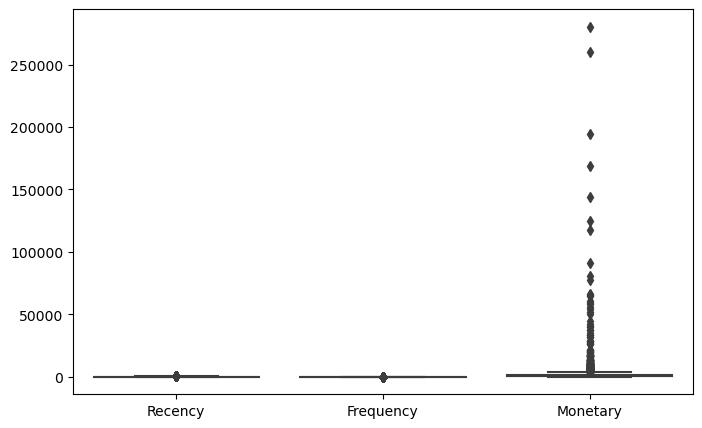

In [46]:
plt.figure(figsize=(8,5))

atribute = ['Recency','Frequency','Monetary']
sns.boxplot(data = rfm[atribute]);

In [47]:
rfm[['Recency','Frequency','Monetary']].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.00,18.000,51.000,142.00,374.00
Frequency,4338.0,4.272015,7.697998,1.00,1.000,2.000,5.00,209.00
Monetary,4338.0,2054.266460,8989.230441,3.75,307.415,674.485,1661.74,280206.02


In [48]:
# Function to summarize distribution and outlier handling recommendation

"""
This function evaluates the distribution of RFM features by comparing mean and median values.
It identifies skewness levels and provides recommendations for handling outliers using log transformation.
"""

def rfm_summary_insight(rfm, columns=['Recency','Frequency','Monetary']):
    summary_list = []
    
    for col in columns:
        mean_val = rfm[col].mean()
        median_val = rfm[col].median()
        max_val = rfm[col].max()
        
        ratio = mean_val / median_val if median_val != 0 else 0
        
        if ratio < 1.3:
            conclusion = 'relatively normal'
            recommendation = 'no transformation needed'
        elif ratio < 2:
            conclusion = 'slightly skewed'
            recommendation = 'optional log transformation'
        elif ratio < 5:
            conclusion = 'highly skewed'
            recommendation = 'log transformation recommended'
        else:
            conclusion = 'extremely skewed'
            recommendation = 'log transformation required'
        
        summary_list.append({
            'Feature': col,
            'Mean': round(mean_val, 2),
            'Median': round(median_val, 2),
            'Max': round(max_val, 2),
            'Conclusion': conclusion,
            'Recommendation': recommendation
        })
    
    return pd.DataFrame(summary_list)

In [49]:
rfm_summary_insight(rfm[['Recency','Frequency','Monetary']])

,Feature,Mean,Median,Max,Conclusion,Recommendation
0,Recency,92.54,51.00,374.00,slightly skewed,optional log transformation
1,Frequency,4.27,2.00,209.00,highly skewed,log transformation recommended
2,Monetary,2054.27,674.49,280206.02,highly skewed,log transformation recommended


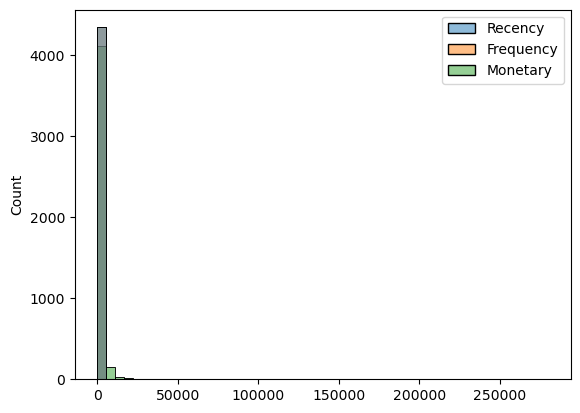

In [50]:
sns.histplot(rfm[atribute], bins = 50);

## 💡 Insight

Based on the comparison between mean, median, and maximum values, the Monetary and Frequency features are highly right-skewed. Therefore, log transformation is applied to reduce the impact of outliers and improve clustering performance.

In [51]:
# Handling Outlier

rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

In [52]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment_RFM,Frequency_log,Monetary_log
0,12346,326,1,77183.60,1,1,5,115,Big Spenders,0.693147,11.253955
1,12347,2,7,4310.00,5,5,5,555,Champions,2.079442,8.368925
2,12348,75,4,1797.24,2,4,4,244,At Risk,1.609438,7.494564
3,12349,19,1,1757.55,4,1,4,414,New Customer,0.693147,7.472245
4,12350,310,1,334.40,1,1,2,112,Regular,0.693147,5.815324


## 🔟 Preprocessing

In [53]:
scaling_rfm = rfm[['Recency','Frequency_log','Monetary_log']]

In [54]:
scaling_rfm.head()

,Recency,Frequency_log,Monetary_log
0,326,0.693147,11.253955
1,2,2.079442,8.368925
2,75,1.609438,7.494564
3,19,0.693147,7.472245
4,310,0.693147,5.815324


In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
scaler = StandardScaler()

In [57]:
rfm_scaler = scaler.fit_transform(scaling_rfm)

In [58]:
rfm_scaler

array([[ 2.33457414, -0.95521426,  3.70622476],
       [-0.90534032,  1.07442519,  1.41184341],
       [-0.17535959,  0.38630445,  0.7164889 ],
       ...,
       [-0.8453419 , -0.36158278, -1.11812113],
       [-0.88534085,  2.17800394,  0.83829669],
       [-0.49535114,  0.05960547,  0.73400231]])

In [59]:
rfm_df = pd.DataFrame(data = rfm_scaler, columns = scaling_rfm.columns, index = rfm['CustomerID'])

In [60]:
rfm_df.head()

,Recency,Frequency_log,Monetary_log
CustomerID,,,
12346,2.334574,-0.955214,3.706225
12347,-0.905340,1.074425,1.411843
12348,-0.175360,0.386304,0.716489
12349,-0.735345,-0.955214,0.698739
12350,2.174578,-0.955214,-0.618962


##  1️⃣1️⃣ Clustering (K-Means)

In [61]:
from sklearn.cluster import KMeans

In [62]:
# Elbow method

ssd = []
for k in range(2, 10):
    kmeans = KMeans(n_clusters = k, max_iter= 300, random_state = 42, n_init = 10)
    kmeans.fit(rfm_df)
    
    ssd.append(kmeans.inertia_)

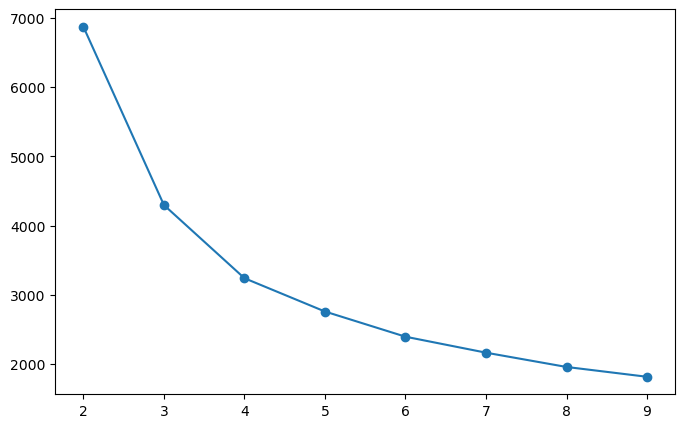

In [63]:
plt.figure(figsize=(8,5))

plt.plot(range(2, 10),ssd, 'o-')
plt.show()

In [64]:
from sklearn.metrics import silhouette_score

In [65]:
# Silhouette score method
for k in range(2, 10):
    kmeans = KMeans(n_clusters = k, max_iter= 300, random_state= 42, n_init = 10)
    model = kmeans.fit(rfm_df)
    cluster_labels = model.labels_
    
    # silhoutte score
    silhouette_avg = silhouette_score(rfm_df, cluster_labels)
    print(f"number clusters = {k}, silhouette score = {silhouette_avg}")

number clusters = 2, silhouette score = 0.4063902704221693
number clusters = 3, silhouette score = 0.4156698333493148
number clusters = 4, silhouette score = 0.380496895821998
number clusters = 5, silhouette score = 0.343347804540966
number clusters = 6, silhouette score = 0.3307776156018078
number clusters = 7, silhouette score = 0.29987993213209757
number clusters = 8, silhouette score = 0.30005861834176634
number clusters = 9, silhouette score = 0.28309590321057954


## 💡 Insight

Based on the Elbow Method and Silhouette Score, the optimal number of clusters is 3. This selection provides a good balance between cluster quality and interpretability in a business context.

## 1️⃣2️⃣  Final Model & Cluster Profiling

In [66]:
model = KMeans(n_clusters = 3, max_iter =300, random_state = 42, n_init = 10)
cluster_model = model.fit(rfm_df)
cluster_model.labels_

array([2, 2, 2, ..., 1, 2, 1])

In [67]:
rfm_df['Cluster'] = cluster_model.labels_

In [68]:
rfm_df.head()

,Recency,Frequency_log,Monetary_log,Cluster
CustomerID,,,,
12346,2.334574,-0.955214,3.706225,2
12347,-0.905340,1.074425,1.411843,2
12348,-0.175360,0.386304,0.716489,2
12349,-0.735345,-0.955214,0.698739,1
12350,2.174578,-0.955214,-0.618962,0


In [69]:
rfm['Cluster'] = rfm_df['Cluster'].values

In [70]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment_RFM,Frequency_log,Monetary_log,Cluster
0,12346,326,1,77183.60,1,1,5,115,Big Spenders,0.693147,11.253955,2
1,12347,2,7,4310.00,5,5,5,555,Champions,2.079442,8.368925,2
2,12348,75,4,1797.24,2,4,4,244,At Risk,1.609438,7.494564,2
3,12349,19,1,1757.55,4,1,4,414,New Customer,0.693147,7.472245,1
4,12350,310,1,334.40,1,1,2,112,Regular,0.693147,5.815324,0
5,12352,36,8,2506.04,3,5,5,355,Regular,2.197225,7.826858,2
6,12353,204,1,89.00,1,1,1,111,Regular,0.693147,4.499810,0
7,12354,232,1,1079.40,1,1,4,114,Big Spenders,0.693147,6.985087,0
8,12355,214,1,459.40,1,1,2,112,Regular,0.693147,6.132096,0
9,12356,23,3,2811.43,4,3,5,435,Regular,1.386294,7.941804,2


In [71]:
# Cluster profiling
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_profile)

            Recency  Frequency     Monetary
Cluster                                    
0        255.029532   1.394094   399.443596
1         54.619094   2.044291   614.456881
2         30.209970   9.825529  5491.373044


In [72]:
# Mapping segment clustering

cluster_map = {
    0: 'Churn Risk', 
    1: 'Regular Customer',
    2: 'Loyal Customer'    
}

rfm['Segment_Cluster'] = rfm['Cluster'].map(cluster_map)

In [73]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment_RFM,Frequency_log,Monetary_log,Cluster,Segment_Cluster
0,12346,326,1,77183.60,1,1,5,115,Big Spenders,0.693147,11.253955,2,Loyal Customer
1,12347,2,7,4310.00,5,5,5,555,Champions,2.079442,8.368925,2,Loyal Customer
2,12348,75,4,1797.24,2,4,4,244,At Risk,1.609438,7.494564,2,Loyal Customer
3,12349,19,1,1757.55,4,1,4,414,New Customer,0.693147,7.472245,1,Regular Customer
4,12350,310,1,334.40,1,1,2,112,Regular,0.693147,5.815324,0,Churn Risk
5,12352,36,8,2506.04,3,5,5,355,Regular,2.197225,7.826858,2,Loyal Customer
6,12353,204,1,89.00,1,1,1,111,Regular,0.693147,4.499810,0,Churn Risk
7,12354,232,1,1079.40,1,1,4,114,Big Spenders,0.693147,6.985087,0,Churn Risk
8,12355,214,1,459.40,1,1,2,112,Regular,0.693147,6.132096,0,Churn Risk
9,12356,23,3,2811.43,4,3,5,435,Regular,1.386294,7.941804,2,Loyal Customer


In [74]:
rfm['Segment_Cluster'].value_counts()

Regular Customer    2032
Loyal Customer      1324
Churn Risk           982
Name: Segment_Cluster, dtype: int64

## 💡 Final Insight

Customers can be grouped into three main segments:

- Cluster 1: Moderate values → Regular Customers
- Cluster 2: Low Recency, High Frequency & Monetary → Loyal Customers
- Cluster 0: High Recency, Low Frequency & Monetary → Churn Risk

This segmentation indicates that the company has a strong opportunity to improve profitability by focusing on retaining high-value customers and reducing churn.

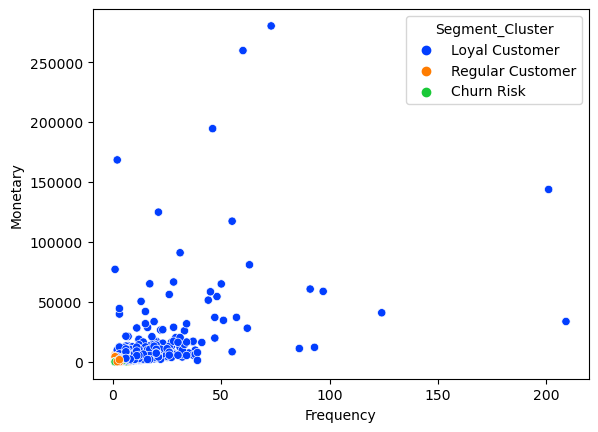

In [75]:
sns.scatterplot(x = 'Frequency', y= 'Monetary', hue='Segment_Cluster', data= rfm, palette='bright');

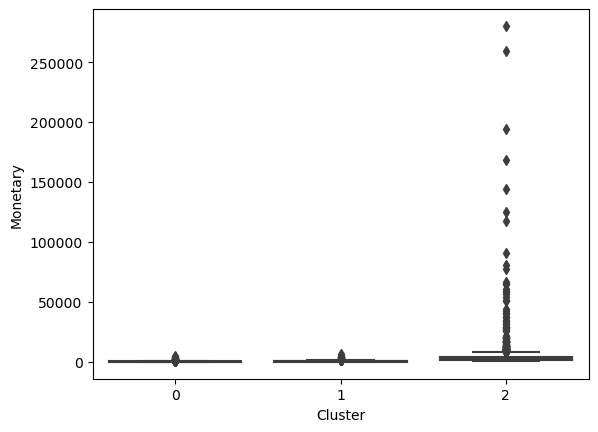

In [76]:
sns.boxplot(x='Cluster', y='Monetary', data=rfm);

## 🧾 Conclusion

The analysis shows that the company’s revenue is highly influenced by a small group of high-value customers. At the same time, there is significant potential loss due to product returns.

By applying RFM analysis and clustering, customers can be segmented into distinct groups with different characteristics. This enables the company to implement more targeted strategies, such as retaining loyal customers, increasing engagement of regular customers, and reducing churn risk.

Overall, this approach can help improve operational efficiency and maximize profitability.

## 📊 Business Impact

If the company can reduce revenue leakage by even 2%, it could significantly increase profit without needing to increase sales.

This highlights that operational optimization can have a direct impact on business profitability.